In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer

In [2]:
def model_builder(reg, name):
    import joblib
    joblib.dump(reg, name+'.pkl')
    return 'done!'

In [3]:
df = pd.read_csv('../data/train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Deleting Outliers

In [4]:
df = df.drop(df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)].index)

In [8]:
# defining the features

features = [
    'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 
    'YearBuilt', 'FullBath', 'TotRmsAbvGrd', 
    'GarageArea'
]

In [9]:
# defining the x and y (question and answer)
x = df[features].copy()
y = df['SalePrice'].copy()

## Before cleaning

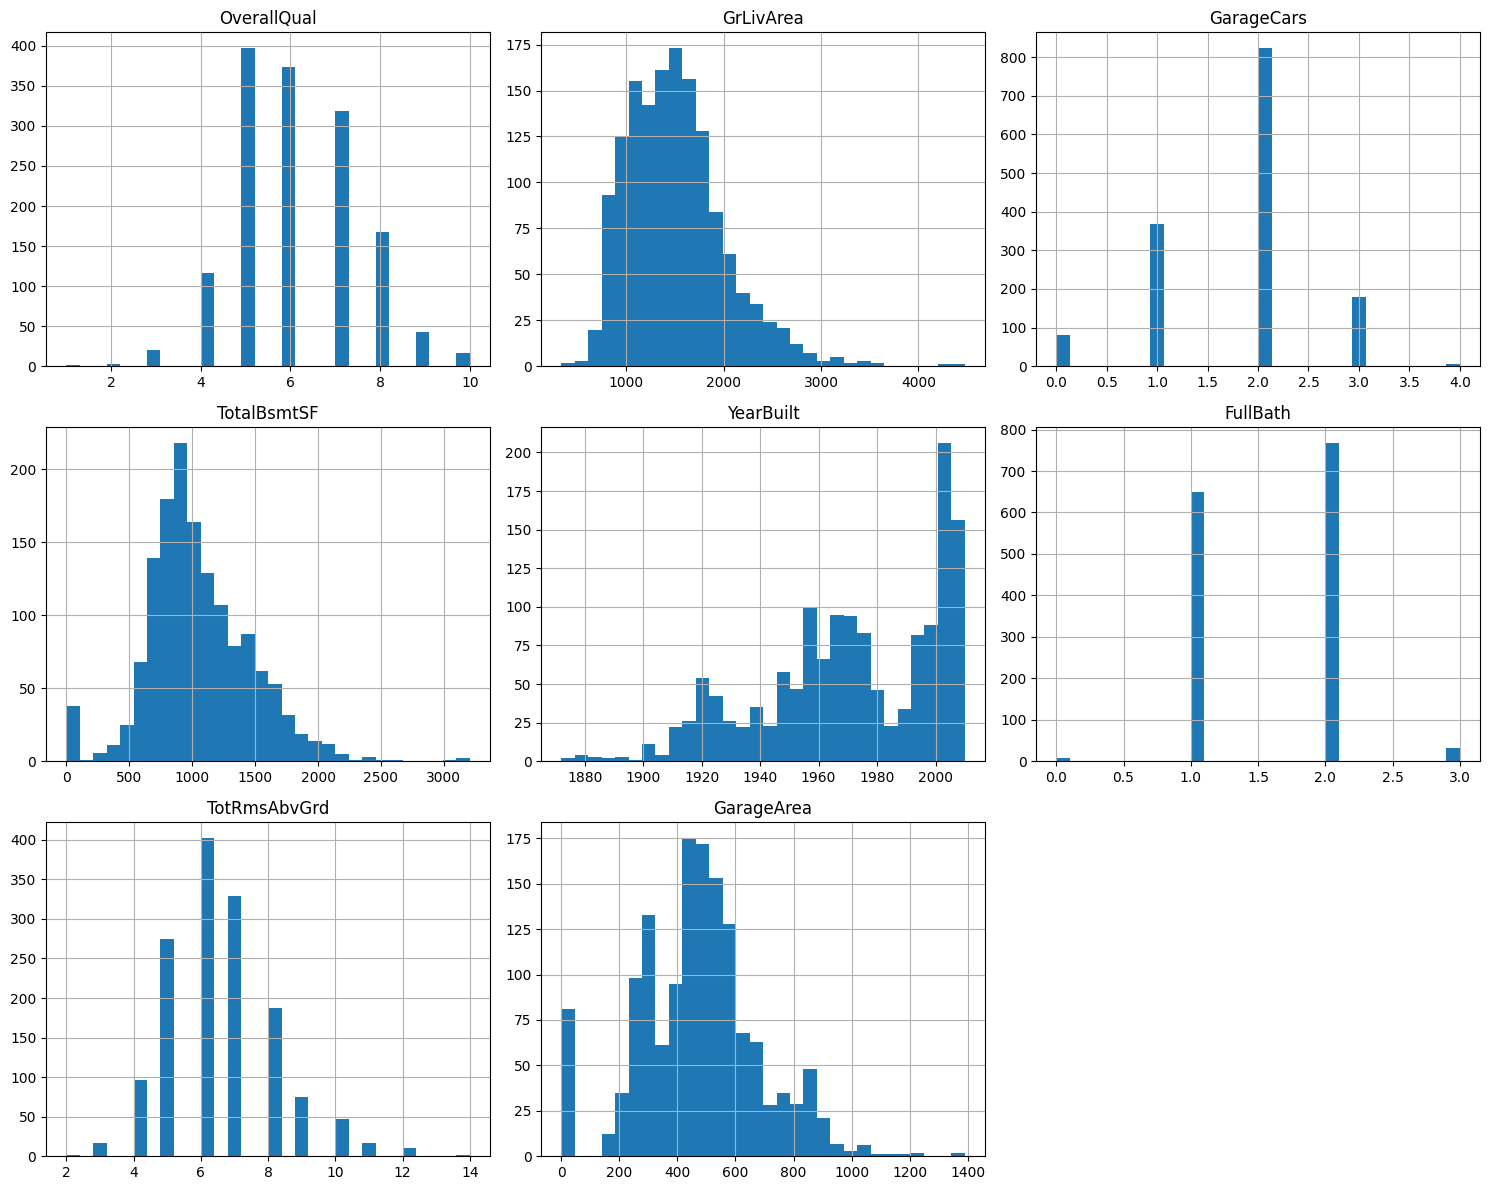

In [10]:
df[features].hist(
    figsize=(15, 12),
    bins=30
);
plt.tight_layout()
plt.show()

In [12]:
skewed_features = ['GrLivArea']
for feat in skewed_features:
    x[feat] = np.log1p(x[feat])

In [13]:
y_log = np.log1p(y)

<Axes: >

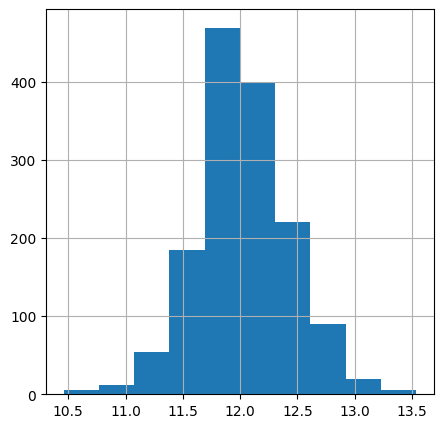

In [14]:
y_log.hist(
    figsize=(5, 5)
)

In [15]:
x_train, x_test, y_train_log, y_test_log = train_test_split(x, y_log, test_size=0.2, random_state=42)

In [17]:
skewed_features = ['GrLivArea']

In [18]:
pass_through_features = [f for f in features if f not in skewed_features]

In [19]:
imputer = SimpleImputer(strategy='median')

In [20]:
log_transformer = FunctionTransformer(np.log1p, validate=False)

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ('skewed', log_transformer, skewed_features),
    ],
    remainder='passthrough' # بقیه ویژگی‌ها بدون تغییر رد شوند
)

In [22]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [23]:
pipeline.fit(x_train, y_train_log)

y_pred_log = pipeline.predict(x_test)
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test_log)

In [24]:
print(f"R2 Score: {r2_score(y_test_actual, y_pred_actual)}")
print(f"MAE: {mean_absolute_error(y_test_actual, y_pred_actual)}")

R2 Score: 0.8537231601562508
MAE: 20338.77921849976


In [25]:
model_builder(pipeline, 'optimized_house_price_pipeline')

'done!'